In [ ]:
#importanos la libreria, subimos el archivo y leemos el dataset completo
import pandas as pd
import numpy as np

# Cargamos el dataset completo
df_raw = pd.read_excel("ewcts_2021_completo.xlsx")
print(f"Dataset completo: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")


Dataset completo: 71758 filas x 358 columnas


In [ ]:
# Filtramos por España
df_spain = df_raw[df_raw["Country"]==10].copy()
print(f"Dataset España: {df_spain.shape[0]} filas x {df_spain.shape[1]} columnas")

df_spain.head()

Dataset España: 2902 filas x 358 columnas


,ID,Country,SurveyCombination_M1,SurveyCombination_M2,workstatus,number_jobs,regular_other_job,number_jobs_filter,job_title,job_activity,...,NACE_broad_groups,EU12,EU15,EA19,IPA,ISCED_11,DEGURBA,URBANITY,NUTS1_Code,NUTS2_Code
298,110001822,10,3,2,1,1,NaN,1.0,NaN,NaN,...,1,1,1,1,0,3,3.0,NaN,ES4,ES42
299,110002984,10,3,2,1,1,NaN,1.0,NaN,NaN,...,1,1,1,1,0,3,1.0,NaN,ES6,ES61
300,110003257,10,1,2,1,1,NaN,1.0,NaN,NaN,...,1,1,1,1,0,4,3.0,NaN,ES6,ES61
301,110003565,10,2,2,1,1,NaN,1.0,NaN,NaN,...,1,1,1,1,0,2,3.0,NaN,ES4,ES43
302,110008288,10,1,1,1,1,NaN,1.0,NaN,NaN,...,1,1,1,1,0,5,2.0,NaN,ES6,ES62


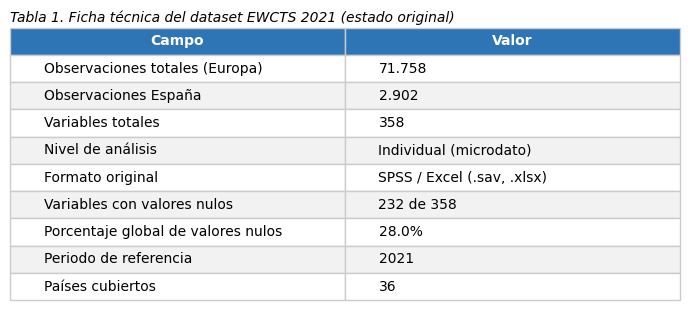

Tabla guardada como tabla1_ficha_tecnica.png


In [ ]:
# Hacemos  TABLA 1: Ficha técnica del dataset original

import pandas as pd
import matplotlib.pyplot as plt

# Calcular los valores
total_obs = len(df_raw)
obs_spain = len(df_spain)
total_vars = df_spain.shape[1]
vars_con_nulos = df_spain.isnull().any().sum()
pct_nulos_global = round(df_spain.isnull().sum().sum() /
                         (df_spain.shape[0] * df_spain.shape[1]) * 100, 1)

# Construir la tabla
ficha = pd.DataFrame({
    "Campo": [
        "Observaciones totales (Europa)",
        "Observaciones España",
        "Variables totales",
        "Nivel de análisis",
        "Formato original",
        "Variables con valores nulos",
        "Porcentaje global de valores nulos",
        "Periodo de referencia",
        "Países cubiertos"
    ],
    "Valor": [
        f"{total_obs:,}".replace(",", "."),
        f"{obs_spain:,}".replace(",", "."),
        str(total_vars),
        "Individual (microdato)",
        "SPSS / Excel (.sav, .xlsx)",
        f"{vars_con_nulos} de {total_vars}",
        f"{pct_nulos_global}%",
        "2021",
        "36"
    ]
})

# Generamos la tabla
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.axis("off")

tabla = ax.table(
    cellText=ficha.values,
    colLabels=["Campo", "Valor"],
    loc="center",
    cellLoc="left"
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 1.6)

# Ponemos el estilo: cabecera azul, filas alternas en gris claro
for (fila, col), celda in tabla.get_celld().items():
    celda.set_edgecolor("#CCCCCC")
    if fila == 0:
        celda.set_facecolor("#2E75B6")
        celda.set_text_props(color="white", fontweight="bold")
    elif fila % 2 == 0:
        celda.set_facecolor("#F2F2F2")
    else:
        celda.set_facecolor("white")

ax.set_title("Tabla 1. Ficha técnica del dataset EWCTS 2021 (estado original)",
             fontsize=10, pad=12, loc="left", style="italic")

plt.tight_layout()
plt.savefig("tabla1_ficha_tecnica.png", bbox_inches="tight", dpi=150)
plt.show()

In [ ]:
# Selección de variables relevantes

# Variable objetivo
target = ["burnout"]

# Demandas laborales
demandas = [
    "usual_hours_week",   # Horas de trabajo semanales
    "highspeed",          # Trabaja a alta velocidad
    "tightdead",          # Plazos muy ajustados
    "emot_disturb",       # Situaciones emocionalmente perturbadoras
    "presenteeism",       # Fue a trabajar estando enfermo
]

# Recursos laborales
recursos = [
    "autonomy_index",     # Índice de autonomía
    "support_manager",    # Apoyo del jefe
    "support_colleagues", # Apoyo de compañeros
    "recognition",        # Reconocimiento del trabajo
    "work_life_balance",  # Conciliación vida-trabajo
]

# Bienestar
bienestar = ["wellbeing_index"]

# Contexto laboral (solo K-Means)
contexto = [
    "wp_size",            # Tamaño del centro de trabajo
    "NACE_broad_groups",  # Sector económico
    "ISCED_11",           # Nivel educativo
]

# Solo EDA y Power BI
eda_only = [
    "gender",             # Género
    "telework",           # Modalidad de teletrabajo
    "empl_contract",      # Tipo de contrato
    "ISCO_1digit",        # Ocupación (ISCO)
]

# Unir todas
all_vars = target + demandas + recursos + bienestar + contexto + eda_only

# Crear dataframe de trabajo
df = df_spain[all_vars].copy()

print(f"Dimensiones del dataset de trabajo: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nVariables seleccionadas ({len(all_vars)}):")
print(all_vars)

Dimensiones del dataset de trabajo: 2902 filas × 19 columnas

Variables seleccionadas (19):
['burnout', 'usual_hours_week', 'highspeed', 'tightdead', 'emot_disturb', 'presenteeism', 'autonomy_index', 'support_manager', 'support_colleagues', 'recognition', 'work_life_balance', 'wellbeing_index', 'wp_size', 'NACE_broad_groups', 'ISCED_11', 'gender', 'telework', 'empl_contract', 'ISCO_1digit']


In [ ]:
# ── PASO 1 corregido: Selección + edad + renombrado ───────────────────────

all_vars = [
    "burnout", "usual_hours_week", "highspeed", "tightdead",
    "emot_disturb", "presenteeism", "autonomy_index", "support_manager",
    "support_colleagues", "recognition", "work_life_balance",
    "wellbeing_index", "wp_size", "NACE_broad_groups", "ISCED_11",
    "gender", "telework", "empl_contract", "ISCO_1digit", "age"
]

df = df_spain[all_vars].copy()

# Renombrar a nombres que se entiendan
df.columns = [
    "burnout",
    "horas_semana",
    "velocidad_alta",
    "plazos_ajustados",
    "demanda_emocional",
    "presentismo",
    "autonomia",
    "apoyo_jefe",
    "apoyo_companeros",
    "reconocimiento",
    "conciliacion",
    "bienestar_who5",
    "tamanio_empresa",
    "sector",
    "nivel_educativo",
    "genero",
    "teletrabajo",
    "tipo_contrato",
    "ocupacion_isco",
    "edad"
]

print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print("\nNombres actuales:")
print(df.columns.tolist())
df.head(3)

Dimensiones: 2902 filas × 20 columnas

Nombres actuales:
['burnout', 'horas_semana', 'velocidad_alta', 'plazos_ajustados', 'demanda_emocional', 'presentismo', 'autonomia', 'apoyo_jefe', 'apoyo_companeros', 'reconocimiento', 'conciliacion', 'bienestar_who5', 'tamanio_empresa', 'sector', 'nivel_educativo', 'genero', 'teletrabajo', 'tipo_contrato', 'ocupacion_isco', 'edad']


,burnout,horas_semana,velocidad_alta,plazos_ajustados,demanda_emocional,presentismo,autonomia,apoyo_jefe,apoyo_companeros,reconocimiento,conciliacion,bienestar_who5,tamanio_empresa,sector,nivel_educativo,genero,teletrabajo,tipo_contrato,ocupacion_isco,edad
298,NaN,42,2,2,1,2,NaN,NaN,NaN,1,1,92.0,1,1,3,1,NaN,NaN,6,48
299,NaN,42,2,2,1,1,NaN,5.0,5.0,1,1,64.0,4,1,3,1,1.0,4.0,9,18
300,NaN,84,4,4,3,1,13.0,NaN,NaN,2,2,64.0,2,1,4,1,NaN,NaN,1,55


In [ ]:
# Vemos valores nulos

# Contar nulos por variable
nulos = df.isnull().sum()
porcentaje = (nulos / len(df) * 100).round(1)

# Crear tabla resumen
resumen_nulos = pd.DataFrame({
    "Valores nulos": nulos,
    "% del total": porcentaje
}).sort_values("% del total", ascending=False)

print(f"Total de filas: {len(df)}\n")
print(resumen_nulos)

Total de filas: 2902

                   Valores nulos  % del total
burnout                     1454         50.1
apoyo_jefe                  1263         43.5
autonomia                    993         34.2
apoyo_companeros             420         14.5
teletrabajo                  420         14.5
tipo_contrato                421         14.5
bienestar_who5                24          0.8
horas_semana                   0          0.0
plazos_ajustados               0          0.0
velocidad_alta                 0          0.0
demanda_emocional              0          0.0
presentismo                    0          0.0
conciliacion                   0          0.0
reconocimiento                 0          0.0
tamanio_empresa                0          0.0
sector                         0          0.0
genero                         0          0.0
nivel_educativo                0          0.0
ocupacion_isco                 0          0.0
edad                           0          0.0


Grupo 1 — Nulos estructurales (no son errores, son diseño de la encuesta):

burnout al 50.1% — Eurofound solo calculó burnout para quienes respondieron ambas preguntas de agotamiento. Los 1.454 nulos son los que quedarán fuera del análisis supervisado, pero el dataset completo se usa para clustering.
apoyo_jefe al 43.5% y apoyo_companeros al 14.5% — estas preguntas solo se hacían a empleados por cuenta ajena, no a autónomos. Es un missing por diseño.
autonomia al 34.2% — el índice no se pudo calcular para quienes no respondieron todas sus subpreguntas.

Grupo 2 — Nulos esperados y tratables:

teletrabajo, tipo_contrato y apoyo_companeros rondando el 14.5% — manejables con imputación.
bienestar_who5 al 0.8% — prácticamente nulo, muy fácil de tratar.

Grupo 3 — Sin nulos:

Todo lo demás tiene 0% — no necesitan ningún tratamiento por missings.

Pero antes de decidir cómo tratar cada uno, hay un problema que tenemos que resolver primero.

In [ ]:
# Convertimos códigos SPSS a NaN

codigos_spss = [-999, -998, -888, -777]

# Contar cuántos hay antes de convertir
total_antes = (df.isin(codigos_spss)).sum().sum()
print(f"Códigos SPSS encontrados antes de convertir: {total_antes}")

# Reemplazar por NaN
df.replace(codigos_spss, np.nan, inplace=True)

# Contar nulos ahora
total_despues = df.isnull().sum().sum()
print(f"Total de NaN tras la conversión: {total_despues}")

# Ver si cambió algo por variable
nulos_nuevos = df.isnull().sum()
porcentaje_nuevo = (nulos_nuevos / len(df) * 100).round(1)

resumen_actualizado = pd.DataFrame({
    "Valores nulos": nulos_nuevos,
    "% del total": porcentaje_nuevo
}).sort_values("% del total", ascending=False)

print("\nTabla actualizada de nulos:")
print(resumen_actualizado)

Códigos SPSS encontrados antes de convertir: 615
Total de NaN tras la conversión: 5610

Tabla actualizada de nulos:
                   Valores nulos  % del total
burnout                     1454         50.1
apoyo_jefe                  1302         44.9
autonomia                    993         34.2
apoyo_companeros             522         18.0
tipo_contrato                445         15.3
teletrabajo                  420         14.5
tamanio_empresa              200          6.9
horas_semana                 140          4.8
reconocimiento                43          1.5
plazos_ajustados              23          0.8
bienestar_who5                24          0.8
conciliacion                  20          0.7
nivel_educativo               10          0.3
demanda_emocional              8          0.3
velocidad_alta                 2          0.1
presentismo                    3          0.1
genero                         0          0.0
sector                         0          0.0
ocupacion_

In [ ]:
# Revisamos los tipos y rangos

print("── Tipos de datos ──")
print(df.dtypes)

print("\n── Estadísticos básicos (variables numéricas) ──")
print(df.describe().round(1).T)

── Tipos de datos ──
burnout              float64
horas_semana         float64
velocidad_alta       float64
plazos_ajustados     float64
demanda_emocional    float64
presentismo          float64
autonomia            float64
apoyo_jefe           float64
apoyo_companeros     float64
reconocimiento       float64
conciliacion         float64
bienestar_who5       float64
tamanio_empresa      float64
sector                 int64
nivel_educativo      float64
genero                 int64
teletrabajo          float64
tipo_contrato        float64
ocupacion_isco         int64
edad                 float64
dtype: object

── Estadísticos básicos (variables numéricas) ──
                    count  mean   std   min   25%   50%   75%    max
burnout            1448.0   2.4   0.8   1.0   2.0   2.0   3.0    4.0
horas_semana       2762.0  39.1  11.1   2.0  36.0  40.0  42.0  105.0
velocidad_alta     2900.0   3.4   1.2   1.0   3.0   3.5   4.0    5.0
plazos_ajustados   2879.0   3.4   1.3   1.0   2.0   3.0   5

Lo que está bien:

velocidad_alta, plazos_ajustados, demanda_emocional — entre 1 y 5 o 1 y 7, todo correcto.

bienestar_who5 — entre 0 y 100, perfecto.
edad — entre 18 y 88, razonable.

**Lo que hay que cambiar:**

*Problema 1* — presentismo tiene máximo 7. El valor 7 significa "no aplica" en el cuestionario original y debe convertirse a NaN. Ahora mismo Python lo está tratando como un número real.

*Problema 2* — horas_semana tiene máximo 105. Nadie trabaja 105 horas semanales de forma real. Hay outliers que hay que tratar.

*Problema 3* — autonomia tiene máximo 15. El rango esperado era 1–5. Esto indica que en el dataset no es la media de las tres subescalas, sino su suma. No es un error, pero hay que saberlo para interpretarlo correctamente.

*Problema 4* — apoyo_jefe tiene máximo 5.0 pero solo 1.600 observaciones válidas. Confirma lo que ya sabíamos: esta variable solo se preguntó a empleados por cuenta ajena.
Resolvemos los dos primeros ahora mismo:


In [1]:
#  Correcciones de rango

#  Presentismo — valor 7 = "no aplica" → NaN
antes = df["presentismo"].isnull().sum()
df["presentismo"] = df["presentismo"].replace(7, np.nan)
despues = df["presentismo"].isnull().sum()
print(f"Presentismo — nulos antes: {antes} → después: {despues}")

# Autonomía — está en escala 3–15, la normalizamos a 1–5
# dividiendo entre 3 para que sea comparable con el resto de recursos
df["autonomia"] = (df["autonomia"] / 3).round(2)
print(f"\nAutonomía — nuevo rango: {df['autonomia'].min():.1f} – {df['autonomia'].max():.1f}")
print(f"(Esperado: 1.0 – 5.0)")

# VERIFICACIÓN: ver los estadísticos de ambas variables corregidas
print("\n── Estadísticos tras corrección ──")
print(df[["presentismo", "autonomia"]].describe().round(2))

NameError: name 'df' is not defined

presentismo — pasó de 3 a 46 nulos. Esos 43 valores que eran "7 = no aplica" ahora son correctamente NaN ✓

autonomia — rango ahora 1.0 a 5.0, perfectamente normalizado ✓

Hay algo curioso en presentismo que vale la pena notar: la media es 1.71 y el máximo es 2.0. Eso significa que casi nadie en España reportó ir a trabajar enfermo con mucha frecuencia. Interesante para la discusión del TFG.

In [ ]:
#PASO 5: Inversión de escalas

# Ver distribución ANTES de invertir
print("── ANTES de invertir ──")
print(f"reconocimiento  — media: {df['reconocimiento'].mean():.2f}, min: {df['reconocimiento'].min()}, max: {df['reconocimiento'].max()}")
print(f"conciliacion    — media: {df['conciliacion'].mean():.2f}, min: {df['conciliacion'].min()}, max: {df['conciliacion'].max()}")

# Invertir escala 1–5 → fórmula: 6 - valor
df["reconocimiento"] = 6 - df["reconocimiento"]
df["conciliacion"]   = 6 - df["conciliacion"]

# Ver distribución DESPUÉS de invertir
print("\n── DESPUÉS de invertir ──")
print(f"reconocimiento  — media: {df['reconocimiento'].mean():.2f}, min: {df['reconocimiento'].min()}, max: {df['reconocimiento'].max()}")
print(f"conciliacion    — media: {df['conciliacion'].mean():.2f}, min: {df['conciliacion'].min()}, max: {df['conciliacion'].max()}")

# Verificamos que los rangos siguen siendo 1–5
print("\n¿Rango correcto (1–5)?")
for var in ["reconocimiento", "conciliacion"]:
    ok = df[var].min() >= 1 and df[var].max() <= 5
    print(f"  {var}: {'✓' if ok else '✗ REVISAR'}")

── ANTES de invertir ──
reconocimiento  — media: 2.23, min: 1.0, max: 5.0
conciliacion    — media: 1.91, min: 1.0, max: 4.0

── DESPUÉS de invertir ──
reconocimiento  — media: 3.77, min: 1.0, max: 5.0
conciliacion    — media: 4.09, min: 2.0, max: 5.0

¿Rango correcto (1–5)?
  reconocimiento: ✓
  conciliacion: ✓


reconocimiento pasó de media 2.23 a 3.77, antes parecía que había poco reconocimiento, ahora leemos correctamente que hay bastante.

conciliacion pasó de 1.91 a 4.09, los trabajadores españoles reportan una conciliación bastante buena en general

In [ ]:
# Vemos el estado actual de nulos

nulos = df.isnull().sum()
porcentaje = (nulos / len(df) * 100).round(1)

resumen = pd.DataFrame({
    "Nulos": nulos,
    "% total": porcentaje
}).sort_values("% total", ascending=False)

# Añadir columna de decisión
def decision(p):
    if p == 0:
        return "✓ Sin nulos"
    elif p <= 5:
        return "→ Imputar"
    elif p <= 15:
        return "→ Imputar con cautela"
    else:
        return "✗ No imputar (estructural)"

resumen["Decisión"] = resumen["% total"].apply(decision)
print(resumen)

                   Nulos  % total                    Decisión
burnout             1454     50.1  ✗ No imputar (estructural)
apoyo_jefe          1302     44.9  ✗ No imputar (estructural)
autonomia            993     34.2  ✗ No imputar (estructural)
apoyo_companeros     522     18.0  ✗ No imputar (estructural)
tipo_contrato        445     15.3  ✗ No imputar (estructural)
teletrabajo          420     14.5       → Imputar con cautela
tamanio_empresa      200      6.9       → Imputar con cautela
horas_semana         140      4.8                   → Imputar
presentismo           46      1.6                   → Imputar
reconocimiento        43      1.5                   → Imputar
bienestar_who5        24      0.8                   → Imputar
plazos_ajustados      23      0.8                   → Imputar
conciliacion          20      0.7                   → Imputar
demanda_emocional      8      0.3                   → Imputar
nivel_educativo       10      0.3                   → Imputar
velocida

Las 5 variables que NO vamos a imputar:

burnout (50.1%), es nuestra variable objetivo. Los nulos no se imputan nunca en la variable que queremos predecir. Los usaremos para clustering pero no para modelos supervisados.

apoyo_jefe (44.9%), solo se preguntó a empleados por cuenta ajena, no tiene sentido imputar la mitad del dataset.

autonomia (34.2%), mismo motivo, missing estructural por diseño.
apoyo_companeros (18.0%) y tipo_contrato (15.3%), superan el umbral y son missings por diseño de la encuesta.

In [ ]:
# Imputación de valores faltantes

# GRUPO 1: (5–15%)
# teletrabajo y tamanio_empresa son variables categóricas → usamos la MODA
# (el valor más frecuente, no la media)

for var in ["teletrabajo", "tamanio_empresa"]:
    moda = df[var].mode()[0]
    nulos_antes = df[var].isnull().sum()
    df[var].fillna(moda, inplace=True)
    print(f"{var}: imputado con moda={moda}  ({nulos_antes} valores)")

# GRUPO 2: (menos del 5%)
# Variables ordinales/Likert → usamos la MEDIANA
# (más robusta que la media ante valores extremos)
vars_mediana = [
    "horas_semana", "presentismo", "reconocimiento",
    "bienestar_who5", "plazos_ajustados", "conciliacion",
    "demanda_emocional", "nivel_educativo", "velocidad_alta"
]

for var in vars_mediana:
    mediana = df[var].median()
    nulos_antes = df[var].isnull().sum()
    df[var].fillna(mediana, inplace=True)
    print(f"{var}: imputado con mediana={mediana}  ({nulos_antes} valores)")

# ── VERIFICACIÓN FINAL ──
print("\n── Nulos restantes tras imputación ──")
restantes = df.isnull().sum()
restantes = restantes[restantes > 0]
print(restantes)
print("\nVariables sin ningún nulo:", (df.isnull().sum() == 0).sum())

teletrabajo: imputado con moda=1.0  (420 valores)
tamanio_empresa: imputado con moda=4.0  (200 valores)
horas_semana: imputado con mediana=40.0  (140 valores)
presentismo: imputado con mediana=2.0  (46 valores)
reconocimiento: imputado con mediana=4.0  (43 valores)
bienestar_who5: imputado con mediana=68.0  (24 valores)
plazos_ajustados: imputado con mediana=3.0  (23 valores)
conciliacion: imputado con mediana=4.0  (20 valores)
demanda_emocional: imputado con mediana=2.0  (8 valores)
nivel_educativo: imputado con mediana=5.0  (10 valores)
velocidad_alta: imputado con mediana=3.5  (2 valores)

── Nulos restantes tras imputación ──
burnout             1454
autonomia            993
apoyo_jefe          1302
apoyo_companeros     522
tipo_contrato        445
edad                   1
dtype: int64

Variables sin ningún nulo: 14


/tmp/ipykernel_1627/1021407429.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[var].fillna(moda, inplace=True)
/tmp/ipykernel_1627/1021407429.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.me

In [ ]:
#  Correcciones

# 1. Imputar el nulo de edad con la mediana
mediana_edad = df["edad"].median()
df["edad"] = df["edad"].fillna(mediana_edad)
print(f"edad: imputado con mediana={mediana_edad} — nulos restantes: {df['edad'].isnull().sum()}")

# 2. Rehacer las imputaciones anteriores con sintaxis moderna (sin warnings)
for var in ["teletrabajo", "tamanio_empresa"]:
    moda = df[var].mode()[0]
    df[var] = df[var].fillna(moda)

vars_mediana = [
    "horas_semana", "presentismo", "reconocimiento",
    "bienestar_who5", "plazos_ajustados", "conciliacion",
    "demanda_emocional", "nivel_educativo", "velocidad_alta"
]
for var in vars_mediana:
    df[var] = df[var].fillna(df[var].median())

# 3. Verificación final
print("\n── Nulos restantes ──")
restantes = df.isnull().sum()
restantes = restantes[restantes > 0]
print(restantes)
print(f"\nVariables completamente limpias: {(df.isnull().sum() == 0).sum()} de {len(df.columns)}")

edad: imputado con mediana=43.0 — nulos restantes: 0

── Nulos restantes ──
burnout             1454
autonomia            993
apoyo_jefe          1302
apoyo_companeros     522
tipo_contrato        445
dtype: int64

Variables completamente limpias: 15 de 20


── Estadísticos actuales ──
count    2902.0
mean       39.1
std        10.8
min         2.0
25%        37.0
50%        40.0
75%        40.0
max       105.0
Name: horas_semana, dtype: float64

Valores > 48h (jornada larga OIT): 369
Valores > 60h:                      61
Valores > 80h:                      11

Percentil 99: 72.0 horas

── Estadísticos tras winsorización ──
count    2902.0
mean       39.0
std        10.4
min         2.0
25%        37.0
50%        40.0
75%        40.0
max        72.0
Name: horas_semana, dtype: float64


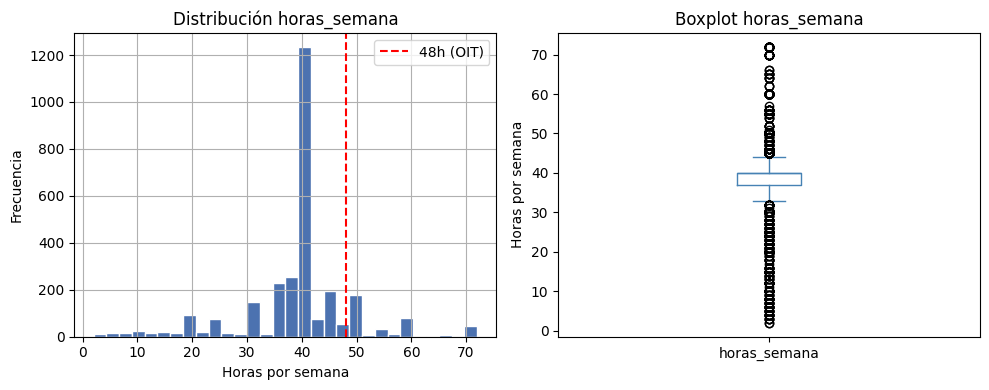

In [ ]:
# Outliers en horas_semana

import matplotlib.pyplot as plt

# 1. Ver distribución actual
print("── Estadísticos actuales ──")
print(df["horas_semana"].describe().round(1))

# 2. Contar valores por encima de umbrales
print(f"\nValores > 48h (jornada larga OIT): {(df['horas_semana'] > 48).sum()}")
print(f"Valores > 60h:                      {(df['horas_semana'] > 60).sum()}")
print(f"Valores > 80h:                      {(df['horas_semana'] > 80).sum()}")

# 3. Calcular percentil 99
p99 = df["horas_semana"].quantile(0.99)
print(f"\nPercentil 99: {p99} horas")

# 4. Aplicar winsorización (cap en percentil 99)
df["horas_semana"] = df["horas_semana"].clip(upper=p99)

print(f"\n── Estadísticos tras winsorización ──")
print(df["horas_semana"].describe().round(1))

# 5. Visualización
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df["horas_semana"].hist(bins=30, ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribución horas_semana")
axes[0].set_xlabel("Horas por semana")
axes[0].set_ylabel("Frecuencia")
axes[0].axvline(48, color="red", linestyle="--", label="48h (OIT)")
axes[0].legend()

df["horas_semana"].plot(kind="box", ax=axes[1], color="steelblue")
axes[1].set_title("Boxplot horas_semana")
axes[1].set_ylabel("Horas por semana")

plt.tight_layout()
plt.show()

Lo que nos dicen los números:

El 12.7% de los trabajadores españoles supera las 48h semanales (370 de 2.902), dato relevante para la discusión.

Solo 11 personas superaban las 80h, esos eran los outliers extremos problemáticos.

El percentil 99 era 72h, que es un límite razonable y justificable.
Tras la winsorización el máximo es 72h  y la media prácticamente no cambió (39.1 → 39.0), señal de que la corrección fue quirúrgica, no agresiva.

Lo que muestran los gráficos:

El histograma tiene un pico clarísimo en 40h — la jornada estándar española. Muy lógico.

El boxplot todavía muestra puntos fuera del bigote superior, pero eso es normal — no son errores, son trabajadores reales con jornadas largas.

In [ ]:
# Crear variable objetivo burnout_bin

# Ver distribución original de burnout
print("── Distribución original de burnout ──")
print(df["burnout"].value_counts(dropna=False).sort_index())
print("\nSignificado de cada categoría:")
print("  1 = Agotamiento físico Y emocional (burnout completo)")
print("  2 = Sin burnout")
print("  3 = Solo agotamiento físico")
print("  4 = Solo agotamiento emocional")

# Crear burnout_bin: 0 = cat2 (sin burnout), 1 = cat1+3+4 (burnout)
df["burnout_bin"] = df["burnout"].apply(
    lambda x: 0 if x == 2 else (1 if x in [1, 3, 4] else np.nan)
)

# Ver distribución de la nueva variable
print("\n── Distribución burnout_bin ──")
print(df["burnout_bin"].value_counts(dropna=False))

total_validos = df["burnout_bin"].notna().sum()
n_burnout = (df["burnout_bin"] == 1).sum()
n_no_burnout = (df["burnout_bin"] == 0).sum()

print(f"\nSobre los {total_validos} casos válidos:")
print(f"  Sin burnout (0): {n_no_burnout} ({n_no_burnout/total_validos*100:.1f}%)")
print(f"  Con burnout (1): {n_burnout}  ({n_burnout/total_validos*100:.1f}%)")

── Distribución original de burnout ──
burnout
1.0      91
2.0     891
3.0     223
4.0     243
NaN    1454
Name: count, dtype: int64

Significado de cada categoría:
  1 = Agotamiento físico Y emocional (burnout completo)
  2 = Sin burnout
  3 = Solo agotamiento físico
  4 = Solo agotamiento emocional

── Distribución burnout_bin ──
burnout_bin
NaN    1454
0.0     891
1.0     557
Name: count, dtype: int64

Sobre los 1448 casos válidos:
  Sin burnout (0): 891 (61.5%)
  Con burnout (1): 557  (38.5%)



Ahora que el dataset está limpio, vamos a crear tres versiones separadas listas para usar directamente en cada fase del análisis:

df_supervisado, solo los 1.448 casos con burnout conocido, para Regresión Logística y Random Forest.
df_clustering, los 2.902 casos completos, para K-Means.
df_eda, el dataset completo con todas las variables, para visualización en Power BI.


In [ ]:
# Preparación de datasets finales

# Variables para modelos supervisados (11 predictores + target)
vars_supervisado = [
    "burnout_bin",
    "horas_semana", "velocidad_alta", "plazos_ajustados",
    "demanda_emocional", "presentismo",
    "apoyo_jefe", "apoyo_companeros", "reconocimiento",
    "conciliacion", "bienestar_who5"
]

# Variables para K-Means (14 variables, sin target)
vars_clustering = [
    "horas_semana", "velocidad_alta", "plazos_ajustados",
    "demanda_emocional", "presentismo",
    "apoyo_jefe", "apoyo_companeros", "reconocimiento",
    "conciliacion", "bienestar_who5",
    "tamanio_empresa", "sector", "nivel_educativo",
    "teletrabajo"
]

#  Dataset supervisado
df_supervisado = df[vars_supervisado].dropna().copy()
df_supervisado["burnout_bin"] = df_supervisado["burnout_bin"].astype(int)

#  Dataset clustering
df_clustering = df[vars_clustering].dropna().copy()

#  Dataset EDA completo
df_eda = df.copy()

#  Resumen
print("── Datasets listos ──")
print(f"df_supervisado : {df_supervisado.shape[0]} filas × {df_supervisado.shape[1]} columnas")
print(f"df_clustering  : {df_clustering.shape[0]} filas × {df_clustering.shape[1]} columnas")
print(f"df_eda         : {df_eda.shape[0]} filas × {df_eda.shape[1]} columnas")

print("\n── Distribución burnout_bin en df_supervisado ──")
counts = df_supervisado["burnout_bin"].value_counts()
total = len(df_supervisado)
for val, count in counts.sort_index().items():
    label = "Sin burnout" if val == 0 else "Con burnout"
    print(f"  {val} ({label}): {count} ({count/total*100:.1f}%)")

print("\n── Primeras 3 filas de df_supervisado ──")
print(df_supervisado.head(3))

── Datasets listos ──
df_supervisado : 654 filas × 11 columnas
df_clustering  : 1532 filas × 14 columnas
df_eda         : 2902 filas × 21 columnas

── Distribución burnout_bin en df_supervisado ──
  0 (Sin burnout): 413 (63.1%)
  1 (Con burnout): 241 (36.9%)

── Primeras 3 filas de df_supervisado ──
     burnout_bin  horas_semana  velocidad_alta  plazos_ajustados  \
311            0          40.0             1.0               1.0   
320            1          35.0             3.0               5.0   
333            0          30.0             5.0               5.0   

     demanda_emocional  presentismo  apoyo_jefe  apoyo_companeros  \
311                1.0          2.0         5.0               5.0   
320                1.0          2.0         5.0               4.0   
333                1.0          2.0         4.0               5.0   

     reconocimiento  conciliacion  bienestar_who5  
311             5.0           5.0           100.0  
320             5.0           4.0            


El dropna() está eliminando todas las filas que tienen NaN en apoyo_jefe o apoyo_companeros, que recordamos que tienen missings estructurales altos (44.9% y 18%). Esas variables solo existen para empleados por cuenta ajena, así que estamos perdiendo a todos los autónomos y a quienes no respondieron esas preguntas.

In [ ]:
print("── Nulos en las variables del modelo supervisado ──")
for var in vars_supervisado:
    n = df[var].isnull().sum()
    pct = n / len(df) * 100
    print(f"  {var:25s}: {n:4d} nulos ({pct:.1f}%)")

── Nulos en las variables del modelo supervisado ──
  burnout_bin              : 1454 nulos (50.1%)
  horas_semana             :    0 nulos (0.0%)
  velocidad_alta           :    0 nulos (0.0%)
  plazos_ajustados         :    0 nulos (0.0%)
  demanda_emocional        :    0 nulos (0.0%)
  presentismo              :    0 nulos (0.0%)
  apoyo_jefe               : 1302 nulos (44.9%)
  apoyo_companeros         :  522 nulos (18.0%)
  reconocimiento           :    0 nulos (0.0%)
  conciliacion             :    0 nulos (0.0%)
  bienestar_who5           :    0 nulos (0.0%)


 Exclumos ambas variables del modelo supervisado y usarlas solo en clustering y EDA. Ventaja: conservas los 1.448 casos válidos y el modelo es representativo de toda la población trabajadora española. Desventaja: pierdes dos predictores importantes de burnout.


In [ ]:


# Variables supervisado SIN apoyo_jefe ni apoyo_companeros
vars_supervisado = [
    "burnout_bin",
    "horas_semana", "velocidad_alta", "plazos_ajustados",
    "demanda_emocional", "presentismo",
    "reconocimiento", "conciliacion", "bienestar_who5"
]

# Variables clustering, las mantenemos todas (apoyo social sí tiene sentido aquí)
vars_clustering = [
    "horas_semana", "velocidad_alta", "plazos_ajustados",
    "demanda_emocional", "presentismo",
    "apoyo_jefe", "apoyo_companeros", "reconocimiento",
    "conciliacion", "bienestar_who5",
    "tamanio_empresa", "sector", "nivel_educativo",
    "teletrabajo"
]

# Datasets finales
df_supervisado = df[vars_supervisado].dropna().copy()
df_supervisado["burnout_bin"] = df_supervisado["burnout_bin"].astype(int)

df_clustering = df[vars_clustering].dropna().copy()

df_eda = df.copy()

# Resumen
print("── Datasets listos ──")
print(f"df_supervisado : {df_supervisado.shape[0]} filas × {df_supervisado.shape[1]} columnas")
print(f"df_clustering  : {df_clustering.shape[0]} filas × {df_clustering.shape[1]} columnas")
print(f"df_eda         : {df_eda.shape[0]} filas × {df_eda.shape[1]} columnas")

print("\n── Distribución burnout_bin en df_supervisado ──")
counts = df_supervisado["burnout_bin"].value_counts().sort_index()
total = len(df_supervisado)
for val, count in counts.items():
    label = "Sin burnout" if val == 0 else "Con burnout"
    print(f"  {val} ({label}): {count} ({count/total*100:.1f}%)")

── Datasets listos ──
df_supervisado : 1448 filas × 9 columnas
df_clustering  : 1532 filas × 14 columnas
df_eda         : 2902 filas × 21 columnas

── Distribución burnout_bin en df_supervisado ──
  0 (Sin burnout): 891 (61.5%)
  1 (Con burnout): 557 (38.5%)


In [ ]:
# Exportar datasets limpios

df_supervisado.to_csv("burnout_supervisado.csv", index=False)
df_clustering.to_csv("burnout_clustering.csv", index=False)
df_eda.to_csv("burnout_eda.csv", index=False)

print("── Archivos exportados ──")
print("  burnout_supervisado.csv")
print("  burnout_clustering.csv")
print("  burnout_eda.csv")

# Descargar automáticamente en Colab
from google.colab import files
files.download("burnout_supervisado.csv")
files.download("burnout_clustering.csv")
files.download("burnout_eda.csv")

── Archivos exportados ──
  burnout_supervisado.csv
  burnout_clustering.csv
  burnout_eda.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#2.1.1 ESTADÍSTICOS DESCRIPTIVOS
Los estadísticos descriptivos nos dan una primera imagen de cómo se distribuyen las variables antes de entrenar ningún modelo. Pero no tiene sentido calcularlos para todas las variables de la misma forma: las variables Likert (escalas del 1 al 5 o 1 al 7) se interpretan de forma distinta a las continuas como horas o bienestar. Lo que nos interesa aquí no es "saber la media por saber la media", sino detectar si hay variables con valores extremos, si las escalas están centradas donde esperamos, y si ya a simple vista alguna variable parece relacionada con el burnout.

Solo analizamos las variables del modelo supervisado más edad y bienestar, porque son las que tienen interpretación directa. Las categóricas (sector, teletrabajo, tipo de contrato) las dejamos para el apartado 2.2.4.

In [ ]:
#  Estadísticos descriptivos
import pandas as pd
import numpy as np

# Variables numéricas con interpretación en burnout
vars_numericas = [
    "horas_semana", "velocidad_alta", "plazos_ajustados",
    "demanda_emocional", "presentismo",
    "autonomia", "reconocimiento", "conciliacion", "bienestar_who5",
    "edad"
]

# Calcular estadísticos relevantes
desc = df_eda[vars_numericas].agg([
    "mean", "median", "std", "min", "max"
]).round(2).T

desc.columns = ["Media", "Mediana", "Desv. típica", "Mínimo", "Máximo"]

# Añadir columna de rango teórico para contexto
rangos = {
    "horas_semana":      "2 – 72",
    "velocidad_alta":    "1 – 7",
    "plazos_ajustados":  "1 – 7",
    "demanda_emocional": "1 – 7",
    "presentismo":       "1 – 6",
    "autonomia":         "1 – 5",
    "reconocimiento":    "1 – 5",
    "conciliacion":      "1 – 5",
    "bienestar_who5":    "0 – 100",
    "edad":              "18 – 88"
}
desc["Rango teórico"] = desc.index.map(rangos)

print("── Estadísticos descriptivos — variables numéricas ──")
print(desc.to_string())

── Estadísticos descriptivos — variables numéricas ──
                   Media  Mediana  Desv. típica  Mínimo  Máximo Rango teórico
horas_semana       38.99    40.00         10.40     2.0    72.0        2 – 72
velocidad_alta      3.42     3.50          1.25     1.0     5.0         1 – 7
plazos_ajustados    3.36     3.00          1.32     1.0     5.0         1 – 7
demanda_emocional   2.40     2.00          1.22     1.0     5.0         1 – 7
presentismo         1.72     2.00          0.45     1.0     2.0         1 – 6
autonomia           3.33     3.33          1.13     1.0     5.0         1 – 5
reconocimiento      3.77     4.00          1.36     1.0     5.0         1 – 5
conciliacion        4.09     4.00          0.89     2.0     5.0         1 – 5
bienestar_who5     67.09    68.00         18.76     0.0   100.0       0 – 100
edad               42.41    43.00         11.22    18.0    88.0       18 – 88


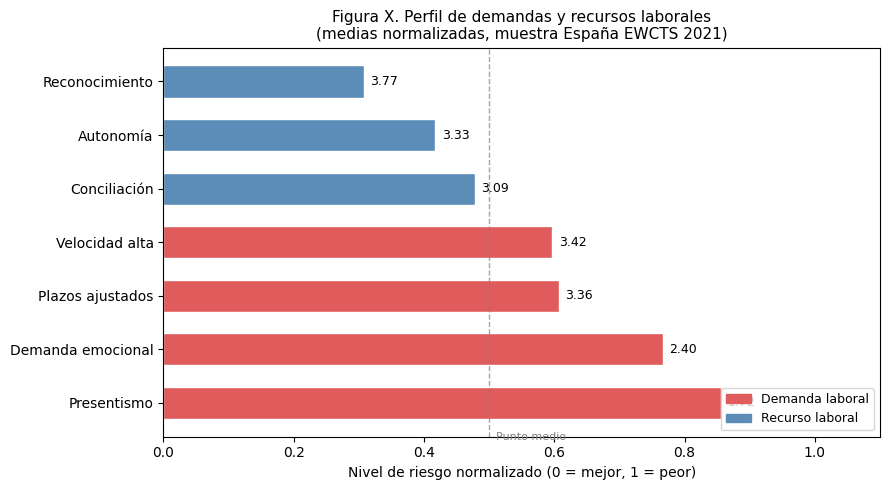

Guardado como grafico_medias_normalizadas.png


In [ ]:
# GRÁFICO 1: Medias normalizadas: demandas vs recursos
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Medias reales la tabla
medias = {
    "Velocidad alta":       3.42,
    "Plazos ajustados":     3.36,
    "Demanda emocional":    2.40,
    "Presentismo":          1.72,
    "Autonomía":            3.33,
    "Reconocimiento":       3.77,
    "Conciliación":         3.09,
}

# Rangos teóricos de cada variable
rangos = {
    "Velocidad alta":       (1, 7),
    "Plazos ajustados":     (1, 7),
    "Demanda emocional":    (1, 7),
    "Presentismo":          (1, 6),
    "Autonomía":            (1, 5),
    "Reconocimiento":       (1, 5),
    "Conciliación":         (1, 5),
}

# Tipos: "demanda" o "recurso"
tipos = {
    "Velocidad alta":    "demanda",
    "Plazos ajustados":  "demanda",
    "Demanda emocional": "demanda",
    "Presentismo":       "demanda",
    "Autonomía":         "recurso",
    "Reconocimiento":    "recurso",
    "Conciliación":      "recurso",
}

# Normalizar: para demandas, valor bajo = peor → invertir
# Para recursos, valor alto = mejor → invertir también para que 1 = peor
valores_norm = {}
for var, media in medias.items():
    mn, mx = rangos[var]
    norm = (media - mn) / (mx - mn)  # 0 a 1
    if tipos[var] == "demanda":
        # escala invertida: 1=siempre (peor) → normalizado alto = peor
        valores_norm[var] = 1 - norm
    else:
        # recurso: valor alto = bueno → invertir para que alto = peor
        valores_norm[var] = 1 - norm

# Colores por tipo
colores = ["#E05C5C" if tipos[v] == "demanda" else "#5B8DB8" for v in medias]

# Ordenar de mayor a menor valor normalizado
orden = sorted(valores_norm, key=valores_norm.get, reverse=True)
vals = [valores_norm[v] for v in orden]
cols = ["#E05C5C" if tipos[v] == "demanda" else "#5B8DB8" for v in orden]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(orden, vals, color=cols, edgecolor="white", height=0.6)

# Línea de punto medio (0.5 = zona neutra)
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.text(0.51, -0.7, "Punto medio", color="gray", fontsize=8)

# Etiquetas con valor original entre paréntesis
for i, (var, val) in enumerate(zip(orden, vals)):
    media_orig = medias[var]
    ax.text(val + 0.01, i, f"{media_orig:.2f}", va="center", fontsize=9)

ax.set_xlim(0, 1.1)
ax.set_xlabel("Nivel de riesgo normalizado (0 = mejor, 1 = peor)", fontsize=10)
ax.set_title("Figura X. Perfil de demandas y recursos laborales\n(medias normalizadas, muestra España EWCTS 2021)", fontsize=11)

leyenda = [
    mpatches.Patch(color="#E05C5C", label="Demanda laboral"),
    mpatches.Patch(color="#5B8DB8", label="Recurso laboral")
]
ax.legend(handles=leyenda, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("grafico_medias_normalizadas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado como grafico_medias_normalizadas.png")

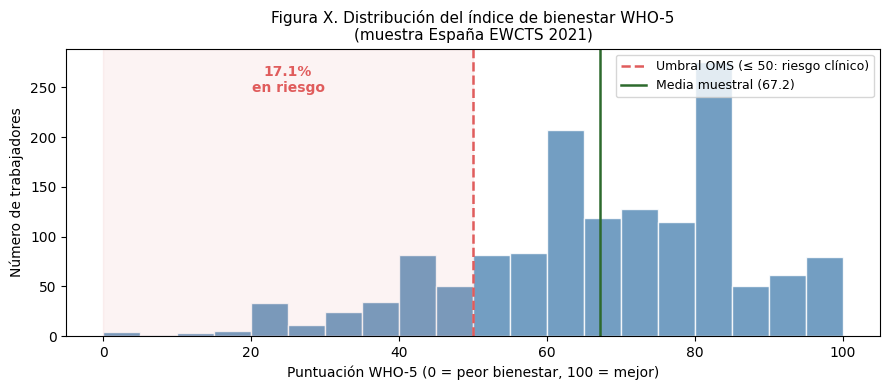

Trabajadores con WHO-5 ≤ 50: 247 (17.1%)
Guardado como grafico_who5.png


In [ ]:
#  GRÁFICO 2: Distribución WHO-5 con umbral clínico

fig, ax = plt.subplots(figsize=(9, 4))

# Histograma
ax.hist(
    df_supervisado["bienestar_who5"].dropna(),
    bins=20,
    color="#5B8DB8",
    edgecolor="white",
    alpha=0.85
)

# Línea de umbral clínico OMS
ax.axvline(50, color="#E05C5C", linestyle="--", linewidth=1.8, label="Umbral OMS (≤ 50: riesgo clínico)")

# Línea de la media
media_who5 = df_supervisado["bienestar_who5"].mean()
ax.axvline(media_who5, color="#2d6a2d", linestyle="-", linewidth=1.8, label=f"Media muestral ({media_who5:.1f})")

# Sombrear zona de riesgo
ax.axvspan(0, 50, alpha=0.07, color="#E05C5C")

# Calcular % en riesgo
n_riesgo = (df_supervisado["bienestar_who5"].dropna() <= 50).sum()
n_total  = df_supervisado["bienestar_who5"].dropna().shape[0]
pct_riesgo = n_riesgo / n_total * 100

ax.text(25, ax.get_ylim()[1] * 0.85 if ax.get_ylim()[1] > 0 else 50,
        f"{pct_riesgo:.1f}%\nen riesgo",
        ha="center", color="#E05C5C", fontsize=10, fontweight="bold")

ax.set_xlabel("Puntuación WHO-5 (0 = peor bienestar, 100 = mejor)", fontsize=10)
ax.set_ylabel("Número de trabajadores", fontsize=10)
ax.set_title("Figura X. Distribución del índice de bienestar WHO-5\n(muestra España EWCTS 2021)", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("grafico_who5.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Trabajadores con WHO-5 ≤ 50: {n_riesgo} ({pct_riesgo:.1f}%)")
print("Guardado como grafico_who5.png")

# 2.2.2 Distribucion de la variable objetivo

Antes de entrenar cualquier modelo supervisado hay que entender cómo está distribuida la variable que queremos predecir (burnout_bin). Si las clases están muy desbalanceadas —por ejemplo, 90% sin burnout y 10% con burnout— el modelo puede aprender simplemente a predecir siempre la clase mayoritaria y aun así tener una precisión aparentemente alta. Por eso necesitamos documentar el desbalance aquí y justificar después cómo lo gestionamos en el modelado.

── Distribución de burnout_bin ──
Sin burnout (0): 891 casos (61.5%)
Con burnout (1): 557 casos (38.5%)
Total válidos:   1448
Ratio desbalance: 1.60:1


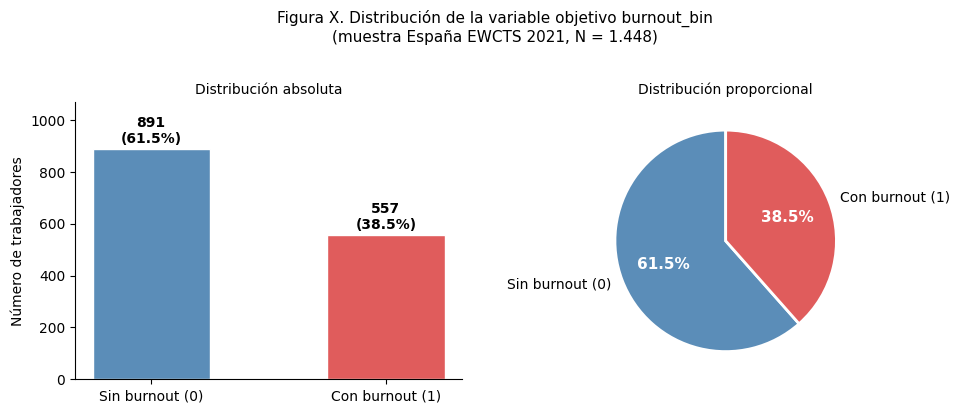

Guardado como grafico_burnout_bin.png


In [ ]:
#  Distribución de la variable objetivo
import matplotlib.pyplot as plt
import numpy as np

# Calcular distribución
conteo = df_supervisado["burnout_bin"].value_counts().sort_index()
etiquetas = ["Sin burnout (0)", "Con burnout (1)"]
colores = ["#5B8DB8", "#E05C5C"]
valores = [conteo[0], conteo[1]]
total = sum(valores)
porcentajes = [v / total * 100 for v in valores]

# Imprimir tabla resumen
print("── Distribución de burnout_bin ──")
print(f"Sin burnout (0): {valores[0]} casos ({porcentajes[0]:.1f}%)")
print(f"Con burnout (1): {valores[1]} casos ({porcentajes[1]:.1f}%)")
print(f"Total válidos:   {total}")
print(f"Ratio desbalance: {porcentajes[0]/porcentajes[1]:.2f}:1")

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#  Panel izquierdo: barras con conteo
bars = axes[0].bar(etiquetas, valores, color=colores, edgecolor="white", width=0.5)
for bar, val, pct in zip(bars, valores, porcentajes):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10,
                 f"{val}\n({pct:.1f}%)",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")

axes[0].set_ylabel("Número de trabajadores", fontsize=10)
axes[0].set_title("Distribución absoluta", fontsize=10)
axes[0].set_ylim(0, max(valores) * 1.2)
axes[0].spines[["top", "right"]].set_visible(False)

#  Panel derecho: gráfico de tarta
wedges, texts, autotexts = axes[1].pie(
    valores,
    labels=etiquetas,
    colors=colores,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
    at.set_color("white")

axes[1].set_title("Distribución proporcional", fontsize=10)

fig.suptitle("Figura X. Distribución de la variable objetivo burnout_bin\n(muestra España EWCTS 2021, N = 1.448)",
             fontsize=11, y=1.02)

plt.tight_layout()
plt.savefig("grafico_burnout_bin.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado como grafico_burnout_bin.png")

#  Histogramas solapados por grupo de burnout
Queremos ver si las variables numéricas se distribuyen de forma distinta entre trabajadores con burnout y sin burnout. Si las distribuciones se solapan mucho, la variable discrimina poco. Si se separan claramente, es una señal de que será un buen predictor en el modelo.

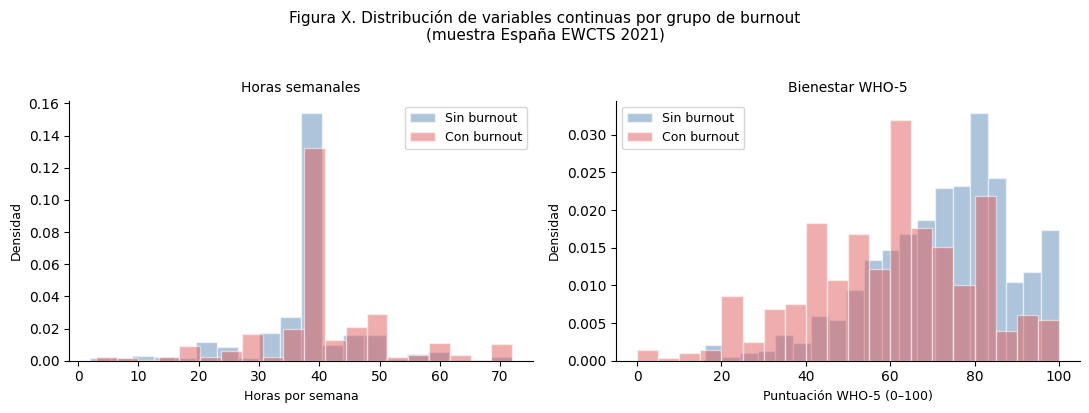

Guardado como grafico_histogramas_bivariado.png


In [ ]:
#  Histogramas solapados por grupo de burnout

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

grupos = {0: "Sin burnout", 1: "Con burnout"}
colores = {0: "#5B8DB8", 1: "#E05C5C"}

for ax, variable, titulo, xlabel in zip(
    axes,
    ["horas_semana", "bienestar_who5"],
    ["Horas semanales", "Bienestar WHO-5"],
    ["Horas por semana", "Puntuación WHO-5 (0–100)"]
):
    for grupo, etiqueta in grupos.items():
        datos = df_supervisado[df_supervisado["burnout_bin"] == grupo][variable].dropna()
        ax.hist(datos, bins=20, alpha=0.5, color=colores[grupo],
                label=etiqueta, edgecolor="white", density=True)

    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel("Densidad", fontsize=9)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Figura X. Distribución de variables continuas por grupo de burnout\n(muestra España EWCTS 2021)",
             fontsize=11, y=1.02)

plt.tight_layout()
plt.savefig("grafico_histogramas_bivariado.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado como grafico_histogramas_bivariado.png")

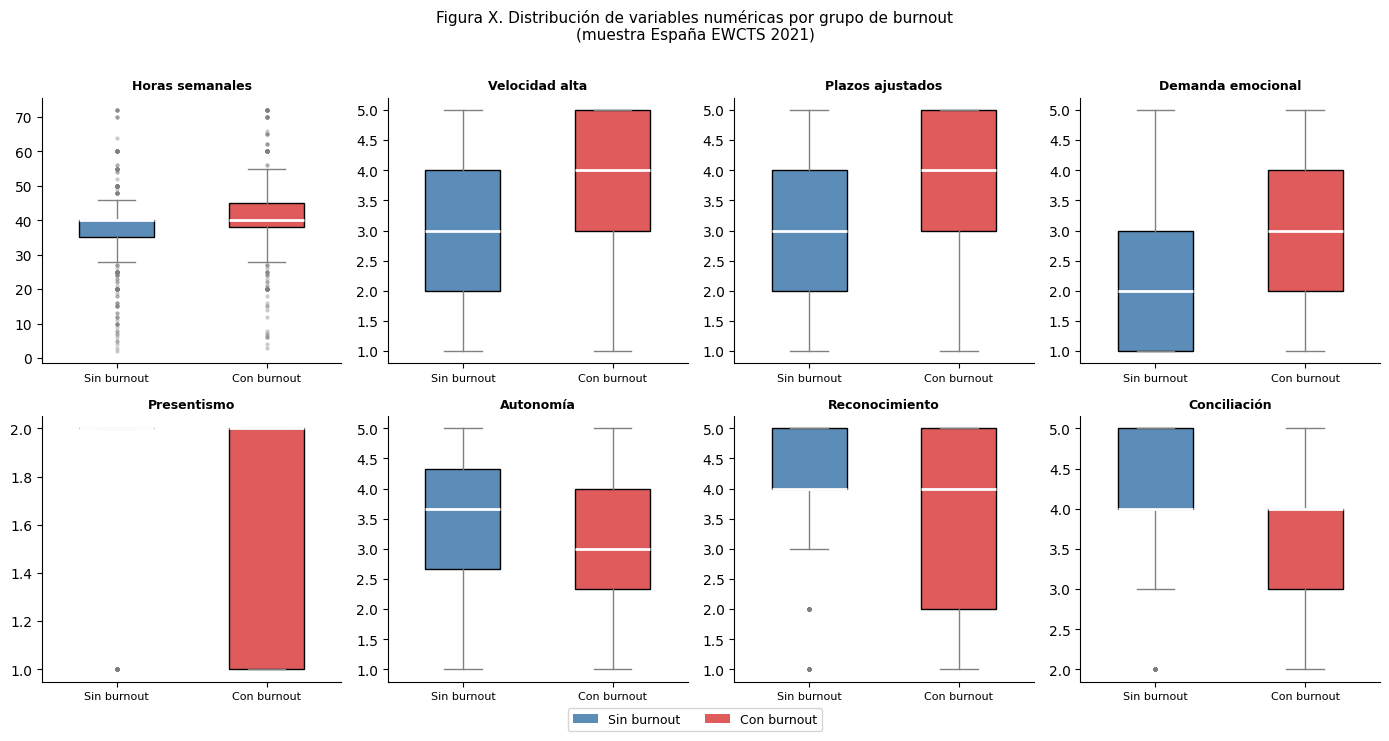

Guardado como grafico_boxplots_bivariado.png


In [ ]:
#  Boxplots por grupo de burnout

vars_boxplot = [
    "horas_semana", "velocidad_alta", "plazos_ajustados",
    "demanda_emocional", "presentismo",
    "autonomia", "reconocimiento", "conciliacion"
]

etiquetas_bonitas = {
    "horas_semana":      "Horas semanales",
    "velocidad_alta":    "Velocidad alta",
    "plazos_ajustados":  "Plazos ajustados",
    "demanda_emocional": "Demanda emocional",
    "presentismo":       "Presentismo",
    "autonomia":         "Autonomía",
    "reconocimiento":    "Reconocimiento",
    "conciliacion":      "Conciliación"
}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

colores = {0: "#5B8DB8", 1: "#E05C5C"}

for i, var in enumerate(vars_boxplot):
    ax = axes[i]
    datos_0 = df_eda[df_eda["burnout_bin"] == 0][var].dropna()
    datos_1 = df_eda[df_eda["burnout_bin"] == 1][var].dropna()

    bp = ax.boxplot(
        [datos_0, datos_1],
        patch_artist=True,
        widths=0.5,
        medianprops={"color": "white", "linewidth": 2}
    )

    bp["boxes"][0].set_facecolor("#5B8DB8")
    bp["boxes"][1].set_facecolor("#E05C5C")

    for whisker in bp["whiskers"]:
        whisker.set_color("gray")
    for cap in bp["caps"]:
        cap.set_color("gray")
    for flier in bp["fliers"]:
        flier.set(marker="o", markerfacecolor="gray",
                  markeredgecolor="none", markersize=3, alpha=0.4)

    ax.set_title(etiquetas_bonitas[var], fontsize=9, fontweight="bold")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Sin burnout", "Con burnout"], fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Figura X. Distribución de variables numéricas por grupo de burnout\n(muestra España EWCTS 2021)",
             fontsize=11, y=1.01)

from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor="#5B8DB8", label="Sin burnout"),
    Patch(facecolor="#E05C5C", label="Con burnout")
]
fig.legend(handles=leyenda, loc="lower center", ncol=2,
           fontsize=9, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig("grafico_boxplots_bivariado.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado como grafico_boxplots_bivariado.png")

# 2.2.4 Variables categóricas


In [ ]:
# Verificar valores únicos antes de recodificar

for var in ["sector", "teletrabajo", "nivel_educativo", "genero"]:
    print(f"\n{var}: {sorted(df_eda[var].dropna().unique().tolist())}")


sector: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

teletrabajo: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]

nivel_educativo: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]

genero: [1, 2, 3]


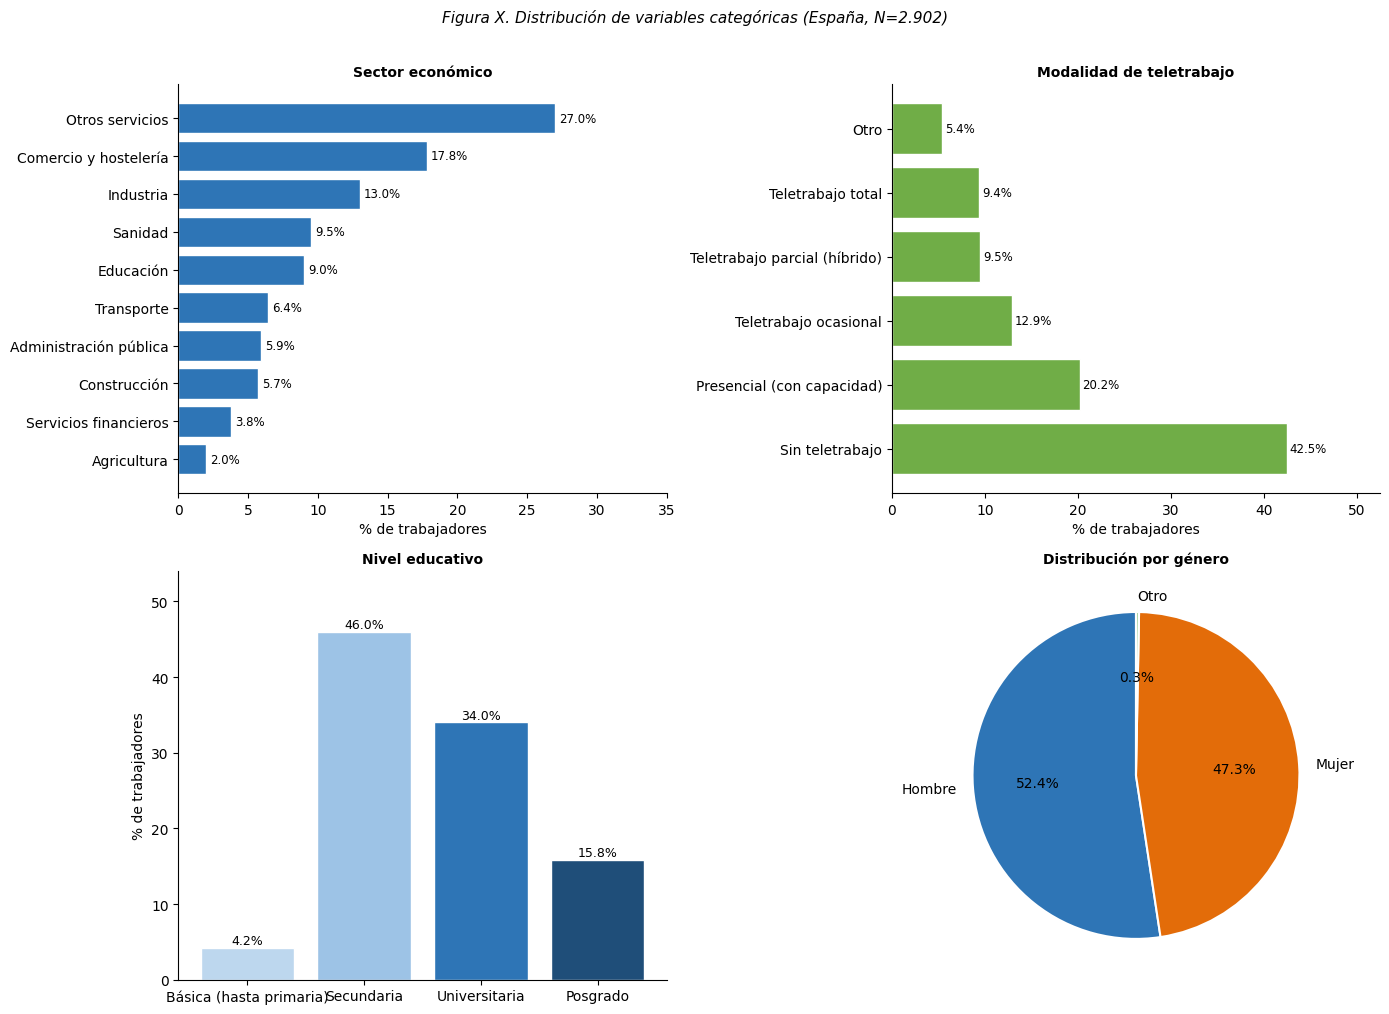

Figura guardada como figura_categoricas.png


In [ ]:
#  Variables categóricas
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

#  Recodificación de etiquetas
df_eda["sector_label"] = df_eda["sector"].map({
    1: "Agricultura",
    2: "Comercio y hostelería",
    3: "Construcción",
    4: "Educación",
    5: "Servicios financieros",
    6: "Sanidad",
    7: "Industria",
    8: "Otros servicios",
    9: "Administración pública",
    10: "Transporte"
})

df_eda["teletrabajo_label"] = df_eda["teletrabajo"].map({
    1: "Sin teletrabajo",
    2: "Presencial (con capacidad)",
    3: "Teletrabajo total",
    4: "Teletrabajo ocasional",
    5: "Otro",
    6: "Teletrabajo parcial (híbrido)"
})

df_eda["educacion_label"] = df_eda["nivel_educativo"].map({
    1: "Educación infantil",
    2: "Educación primaria",
    3: "Secundaria inferior",
    4: "Secundaria superior",
    5: "Post-secundaria no terciaria",
    6: "Terciaria ciclo corto",
    7: "Grado universitario",
    8: "Máster",
    9: "Doctorado"
})

df_eda["genero_label"] = df_eda["genero"].map({
    1: "Hombre",
    2: "Mujer",
    3: "Otro"
})

#  Figura: 4 gráficos en 2×2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Figura X. Distribución de variables categóricas (España, N=2.902)",
             fontsize=11, style="italic", y=1.01)

color_base = "#2E75B6"

# Gráfico 1: Sector
sector_counts = df_eda["sector_label"].value_counts().sort_values(ascending=True)
sector_pct = (sector_counts / sector_counts.sum() * 100).round(1)
bars = axes[0, 0].barh(sector_pct.index, sector_pct.values,
                        color=color_base, edgecolor="white")
for bar, val in zip(bars, sector_pct.values):
    axes[0, 0].text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                    f"{val}%", va="center", fontsize=8.5)
axes[0, 0].set_title("Sector económico", fontsize=10, fontweight="bold")
axes[0, 0].set_xlabel("% de trabajadores")
axes[0, 0].set_xlim(0, sector_pct.max() + 8)
axes[0, 0].spines["top"].set_visible(False)
axes[0, 0].spines["right"].set_visible(False)

#  Gráfico 2: Teletrabajo
tw_order = ["Sin teletrabajo", "Presencial (con capacidad)",
            "Teletrabajo ocasional", "Teletrabajo parcial (híbrido)",
            "Teletrabajo total", "Otro"]
tw_counts = df_eda["teletrabajo_label"].value_counts()
tw_counts = tw_counts.reindex([x for x in tw_order if x in tw_counts.index])
tw_pct = (tw_counts / tw_counts.sum() * 100).round(1)
bars2 = axes[0, 1].barh(tw_pct.index, tw_pct.values,
                         color="#70AD47", edgecolor="white")
for bar, val in zip(bars2, tw_pct.values):
    axes[0, 1].text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                    f"{val}%", va="center", fontsize=8.5)
axes[0, 1].set_title("Modalidad de teletrabajo", fontsize=10, fontweight="bold")
axes[0, 1].set_xlabel("% de trabajadores")
axes[0, 1].set_xlim(0, tw_pct.max() + 10)
axes[0, 1].spines["top"].set_visible(False)
axes[0, 1].spines["right"].set_visible(False)

#  Gráfico 3: Nivel educativo (agrupado en 4 niveles)
df_eda["educacion_agrupada"] = df_eda["nivel_educativo"].map({
    1: "Básica (hasta primaria)",
    2: "Básica (hasta primaria)",
    3: "Secundaria",
    4: "Secundaria",
    5: "Secundaria",
    6: "Universitaria",
    7: "Universitaria",
    8: "Posgrado",
    9: "Posgrado"
})
edu_order = ["Básica (hasta primaria)", "Secundaria",
             "Universitaria", "Posgrado"]
edu_counts = df_eda["educacion_agrupada"].value_counts()
edu_counts = edu_counts.reindex([x for x in edu_order if x in edu_counts.index])
edu_pct = (edu_counts / edu_counts.sum() * 100).round(1)
colors_edu = ["#BDD7EE", "#9DC3E6", "#2E75B6", "#1F4E79"]
axes[1, 0].bar(edu_pct.index, edu_pct.values,
               color=colors_edu[:len(edu_pct)], edgecolor="white")
for i, val in enumerate(edu_pct.values):
    axes[1, 0].text(i, val + 0.5, f"{val}%",
                    ha="center", fontsize=9)
axes[1, 0].set_title("Nivel educativo", fontsize=10, fontweight="bold")
axes[1, 0].set_ylabel("% de trabajadores")
axes[1, 0].set_ylim(0, edu_pct.max() + 8)
axes[1, 0].spines["top"].set_visible(False)
axes[1, 0].spines["right"].set_visible(False)

#  Gráfico 4: Género
gen_counts = df_eda["genero_label"].value_counts()
gen_pct = (gen_counts / gen_counts.sum() * 100).round(1)
colores_gen = ["#2E75B6", "#E36C09", "#A8D5A2"]
wedges, texts, autotexts = axes[1, 1].pie(
    gen_pct.values,
    labels=gen_pct.index,
    autopct="%1.1f%%",
    colors=colores_gen[:len(gen_pct)],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
for t in autotexts:
    t.set_fontsize(10)
axes[1, 1].set_title("Distribución por género", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("figura_categoricas.png", bbox_inches="tight", dpi=150)
plt.show()
print("Figura guardada como figura_categoricas.png")

In [ ]:
#  Ver codificación de tipo_contrato y ocupacion_isco
for var in ["tipo_contrato", "ocupacion_isco"]:
    print(f"\n── {var} ──")
    print(df_eda[var].value_counts(dropna=False).sort_index())


── tipo_contrato ──
tipo_contrato
1.0    1833
2.0     411
3.0      28
4.0      21
5.0      31
6.0     133
NaN     445
Name: count, dtype: int64

── ocupacion_isco ──
ocupacion_isco
0      8
1    231
2    818
3    365
4    380
5    423
6     55
7    248
8    158
9    216
Name: count, dtype: int64


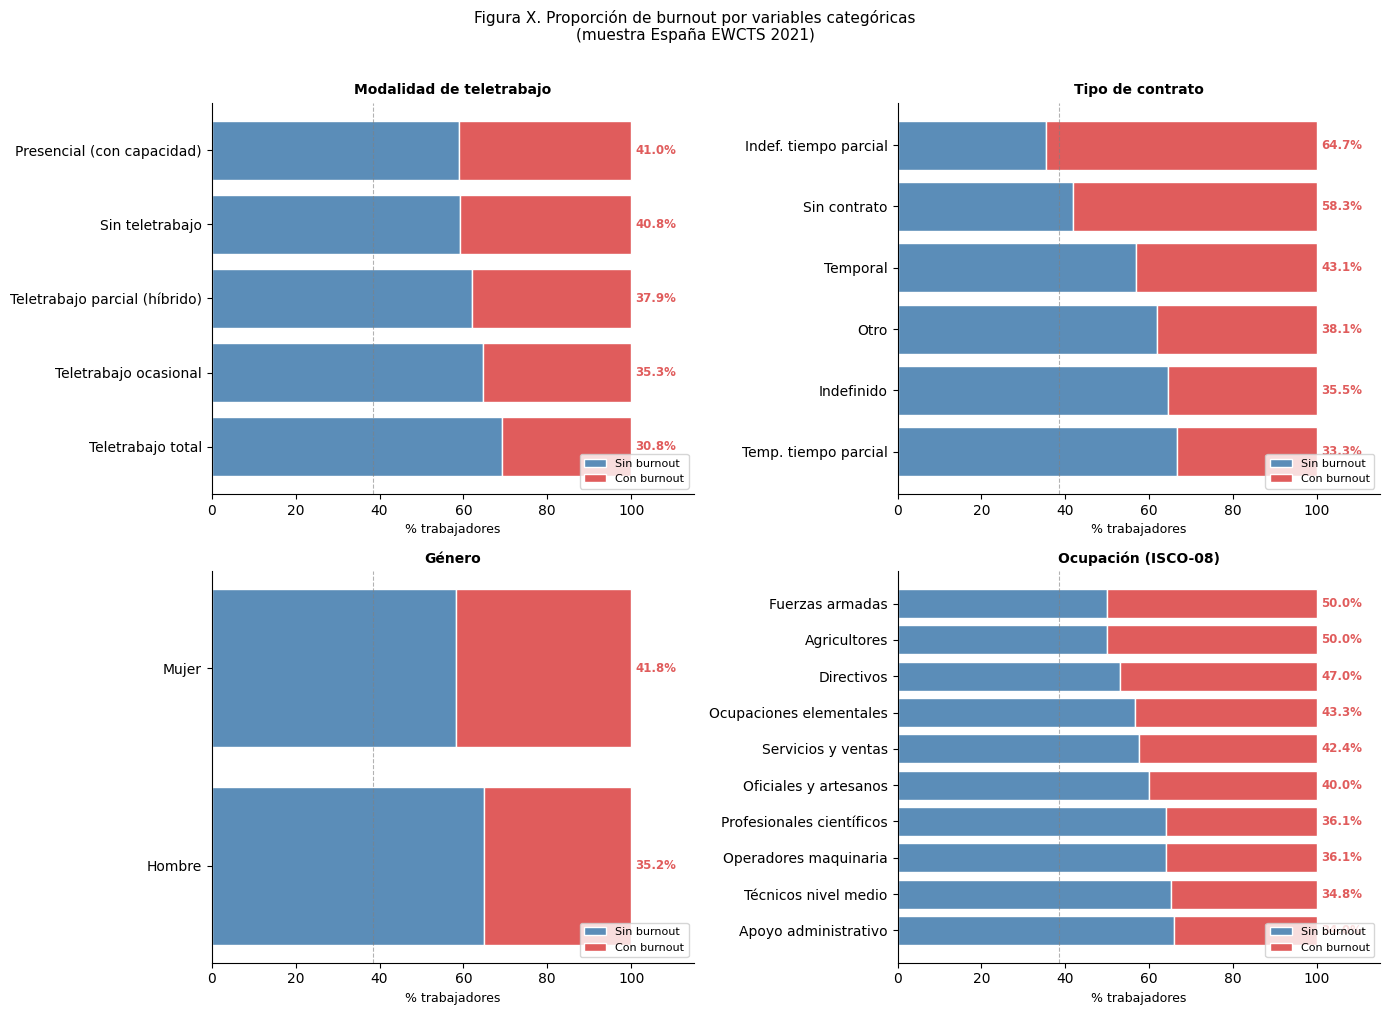

Guardado como grafico_categoricas_burnout.png


In [ ]:
#   Variables categóricas cruzadas con burnout_bin

# Trabajamos con df_eda que tiene burnout_bin y todas las categóricas
# Filtramos solo casos con burnout_bin válido
df_cat = df_eda[df_eda["burnout_bin"].notna()].copy()

# ── Recodificaciones ──
df_cat["teletrabajo_label"] = df_cat["teletrabajo"].map({
    1: "Sin teletrabajo",
    2: "Presencial (con capacidad)",
    3: "Teletrabajo total",
    4: "Teletrabajo ocasional",
    6: "Teletrabajo parcial (híbrido)"
})

df_cat["contrato_label"] = df_cat["tipo_contrato"].map({
    1: "Indefinido",
    2: "Temporal",
    3: "Indef. tiempo parcial",
    4: "Temp. tiempo parcial",
    5: "Sin contrato",
    6: "Otro"
})

df_cat["genero_label"] = df_cat["genero"].map({
    1: "Hombre",
    2: "Mujer"
})

df_cat["ocupacion_label"] = df_cat["ocupacion_isco"].map({
    0: "Fuerzas armadas",
    1: "Directivos",
    2: "Profesionales científicos",
    3: "Técnicos nivel medio",
    4: "Apoyo administrativo",
    5: "Servicios y ventas",
    6: "Agricultores",
    7: "Oficiales y artesanos",
    8: "Operadores maquinaria",
    9: "Ocupaciones elementales"
})

#  Función para calcular % burnout por grupo
def pct_burnout(df, variable):
    tabla = df.groupby(variable)["burnout_bin"].agg(
        total="count",
        con_burnout="sum"
    ).reset_index()
    tabla["pct_burnout"] = (tabla["con_burnout"] / tabla["total"] * 100).round(1)
    tabla["pct_no_burnout"] = 100 - tabla["pct_burnout"]
    return tabla.dropna(subset=[variable]).sort_values("pct_burnout", ascending=True)

#  Gráfico 2×2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Figura X. Proporción de burnout por variables categóricas\n(muestra España EWCTS 2021)",
             fontsize=11, y=1.01)

variables = [
    ("teletrabajo_label", "Modalidad de teletrabajo"),
    ("contrato_label",    "Tipo de contrato"),
    ("genero_label",      "Género"),
    ("ocupacion_label",   "Ocupación (ISCO-08)")
]

for ax, (var, titulo) in zip(axes.flatten(), variables):
    tabla = pct_burnout(df_cat, var)

    # Barras apiladas al 100%
    ax.barh(tabla[var], tabla["pct_no_burnout"],
            color="#5B8DB8", label="Sin burnout", edgecolor="white")
    ax.barh(tabla[var], tabla["pct_burnout"],
            left=tabla["pct_no_burnout"],
            color="#E05C5C", label="Con burnout", edgecolor="white")

    # Etiqueta % burnout al final de cada barra
    for _, row in tabla.iterrows():
        if row["pct_burnout"] >= 5:
            ax.text(101, list(tabla[var]).index(row[var]),
                    f"{row['pct_burnout']}%",
                    va="center", fontsize=8.5, color="#E05C5C", fontweight="bold")

    ax.set_xlim(0, 115)
    ax.axvline(38.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_xlabel("% trabajadores", fontsize=9)
    ax.set_title(titulo, fontsize=10, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("grafico_categoricas_burnout.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado como grafico_categoricas_burnout.png")

# Matriz de correlación

La matriz de correlaciones nos permite ver de un vistazo qué variables están relacionadas entre sí y con la variable objetivo burnout_bin. Esto es útil por dos razones: primero, para identificar qué predictores tienen más relación directa con el burnout; segundo, para detectar si hay variables muy correlacionadas entre sí (multicolinealidad), lo cual puede afectar al modelo de regresión logística.



── Correlaciones con Burnout (ordenadas) ──
Bienestar WHO-5     -0.32
Conciliación        -0.31
Velocidad alta       0.31
Demanda emocional    0.30
Presentismo         -0.22
Reconocimiento      -0.22
Plazos ajustados     0.22
Autonomía           -0.16
Horas semanales      0.14


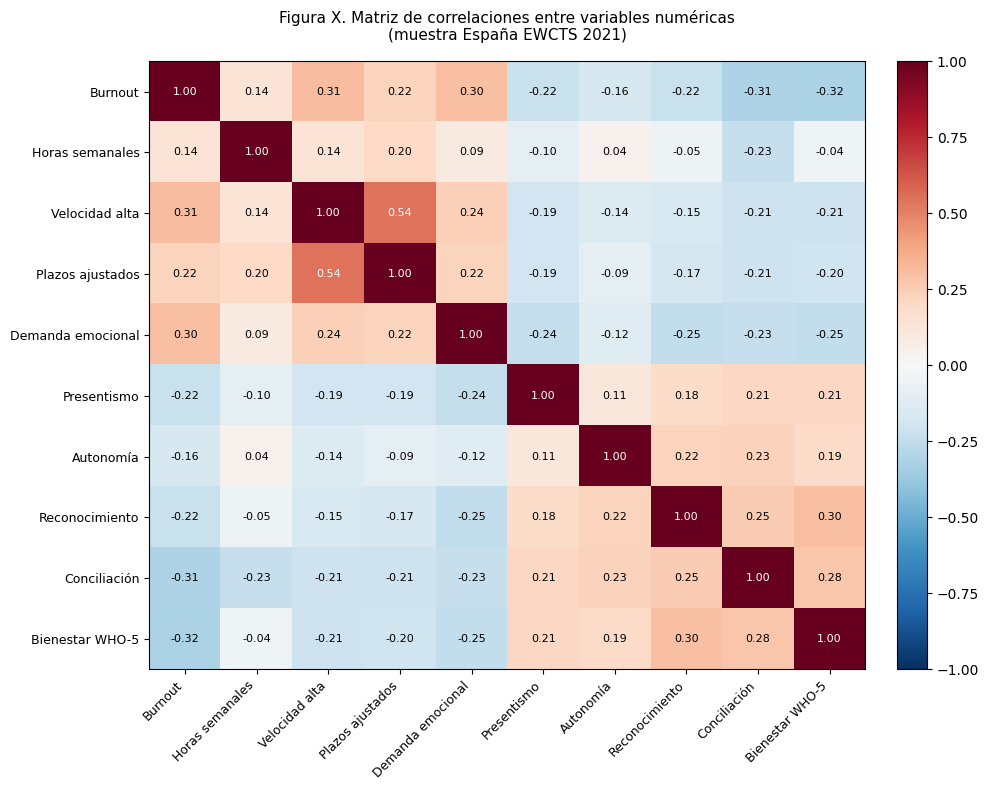

Guardado como grafico_correlaciones.png


In [ ]:
#  Matriz de correlaciones
import matplotlib.pyplot as plt
import numpy as np

# Variables a incluir
vars_corr = [
    "burnout_bin", "horas_semana", "velocidad_alta", "plazos_ajustados",
    "demanda_emocional", "presentismo", "autonomia",
    "reconocimiento", "conciliacion", "bienestar_who5"
]

# Etiquetas legibles
etiquetas = {
    "burnout_bin":       "Burnout",
    "horas_semana":      "Horas semanales",
    "velocidad_alta":    "Velocidad alta",
    "plazos_ajustados":  "Plazos ajustados",
    "demanda_emocional": "Demanda emocional",
    "presentismo":       "Presentismo",
    "autonomia":         "Autonomía",
    "reconocimiento":    "Reconocimiento",
    "conciliacion":      "Conciliación",
    "bienestar_who5":    "Bienestar WHO-5"
}

# Calcular correlaciones usando df_eda (tiene todas las variables)
df_corr = df_eda[vars_corr].rename(columns=etiquetas)
matriz = df_corr.corr(numeric_only=True).round(2)

# Imprimir correlaciones con burnout ordenadas
print("── Correlaciones con Burnout (ordenadas) ──")
corr_burnout = matriz["Burnout"].drop("Burnout").sort_values(key=abs, ascending=False)
print(corr_burnout.to_string())

#  Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(matriz.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Etiquetas de ejes
ax.set_xticks(range(len(matriz.columns)))
ax.set_yticks(range(len(matriz.index)))
ax.set_xticklabels(matriz.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(matriz.index, fontsize=9)

# Valores dentro de cada celda
for i in range(len(matriz)):
    for j in range(len(matriz.columns)):
        val = matriz.values[i, j]
        color = "white" if abs(val) > 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=8, color=color)

ax.set_title("Figura X. Matriz de correlaciones entre variables numéricas\n(muestra España EWCTS 2021)",
             fontsize=11, pad=15)

plt.tight_layout()
plt.savefig("grafico_correlaciones.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado como grafico_correlaciones.png")